<a href="https://colab.research.google.com/github/nicole-kutswa/Data-Science-Certification-Data-Camp-/blob/Main/unsupervisedml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [13]:
np.random.seed(42)

In [14]:
df = pd.DataFrame({
    'experience': np.random.randint(1, 20, 150),
    'salary':     np.random.randint(3000, 8000, 150),
    'score':      np.random.randint(60, 100, 150),
    'age':        np.random.randint(22, 60, 150),
    'hours_worked': np.random.randint(30, 60, 150)
})

In [15]:
df.head()

,experience,salary,score,age,hours_worked
0,7,7779,80,50,50
1,15,3663,91,47,49
2,11,4998,82,31,42
3,8,6445,92,47,57
4,7,6743,62,55,45


In [16]:
columns= df[['experience','salary','score','age','hours_worked' ]]
X= columns
scaler= StandardScaler()
X_scaled= scaler.fit_transform(X)

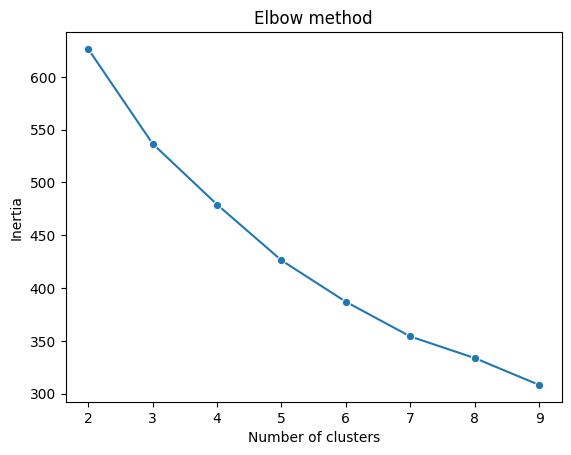

[626.5046378170774, 536.7254259749476, 479.1168330009387, 426.2557826977173, 386.98494132937265, 354.11918240540626, 333.6765593667552, 308.2175316522146]


In [17]:
inertia= []

k_range= range(2, 10)

for k in k_range:
  km= KMeans(n_clusters= k, random_state= 42, n_init= 10)
  km.fit(X_scaled)
  inertia.append(km.inertia_)

sns.lineplot(x= k_range, y= inertia, marker= 'o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.show()

print(inertia)

In [18]:
cluster= [2, 3, 4]
for k in cluster:
  Km= KMeans(n_clusters= k, random_state= 42, n_init= 10)
  labels= Km.fit_predict(X_scaled)
  score= silhouette_score(X_scaled, labels)
  print(f'Silhouette score for {k} clusters: {score}')



Silhouette score for 2 clusters: 0.1521104175147151
Silhouette score for 3 clusters: 0.17167013124205832
Silhouette score for 4 clusters: 0.16536109163810175


In [19]:
KM= KMeans(n_clusters= 3, random_state= 42, n_init= 10)
labels= KM.fit_predict(X_scaled)
df['cluster']= labels

df.groupby('cluster').agg({
    'experience': 'mean',
    'salary': 'mean'
})


,experience,salary
cluster,,
0,12.456522,4277.23913
1,9.916667,6956.12500
2,6.321429,5606.50000


In [20]:
pca= PCA(n_components= 2)
X_pca= pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())


[0.2380354  0.22071402]
0.45874942457626255


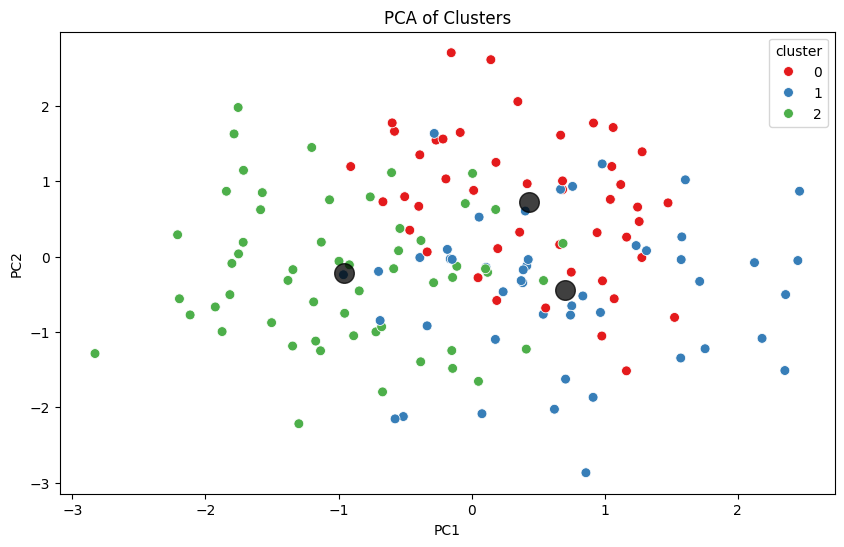

In [23]:
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = df['cluster']

plt.figure(figsize= (10, 6))
sns.scatterplot(x='PC1', y= 'PC2', hue= 'cluster', data= pca_df, palette= 'Set1', s= 50)

centroids_pca= pca.transform(KM.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c= 'black', s= 200, alpha= 0.75)
plt.title('PCA of Clusters')
plt.show()

In [ ]:
#adding more principal components increases the risk of overfitting